In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import great_tables as gt

In [2]:
df = pl.read_parquet("data/donnees_finales.parquet")

Quelques valeurs globales

In [3]:
# Calcul du nombre total d'athlètes global et par sexe
total = df.shape[0]
total_h = df.filter(pl.col("sex") == "M").shape[0]
total_f = df.filter(pl.col("sex") == "F").shape[0]

### Distribution des temps par sexe sous contrainte de quantile

In [4]:
def distrib_tps(quantile:float):
    """Renvoie un histogramme représentant la distribution des temps avec une précision
    à la minute près répartis selon le sexe et ne considérant que la part demandée selon
    le quantile donné."""

    # Calcul de la valeur quantile et conversion en minutes
    q = df["realTime"].quantile(quantile)
    q_min = q / 60

    # Calcul du nombre de coureurs ayant fini au-delà du temps max représenté
    nb_sup_q = df.filter(pl.col("realTime") > q).shape[0]

    # Conversion en minutes
    df_plot = df.with_columns(
        (pl.col("realTime") / 60).alias("realTime_min")
    ).to_pandas()

    # Code de l'histogramme
    sns.histplot(
        data=df_plot,
        x="realTime_min",
        hue="sex",  # couleur définie par la colonne sex
        binwidth=1,  # 1 barre = 1 minute
    )


    def format_minutes(x, pos):
        """Convertit un nmobre de secondes au format H:MM."""
        h = int(x // 60)
        m = int(x % 60)
        return f"{h}:{m:02d}"

    # Formatage des axes
    ax = plt.gca()
    ax.set_xlim(120, q_min)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_minutes))

    # Légende et affichage du graphe
    plt.xlabel("Temps réel")
    plt.ylabel("Nombre de coureurs")
    plt.title(f"Distribution des temps par sexe des {quantile*100}% premiers concurrents")
    plt.show()

    # Conversion de la valeur quantile en H:MM:SS
    h = int(q) // 3600
    m = (int(q) % 3600) // 60
    s = int(q) % 60
    print(f"On observe que {nb_sup_q} coureurs ont fini en plus de {h}:{m:02d}:{s:02d}.")

### Répartitions des coureurs selon les seuils symboliques

In [5]:
def repart_seuils():
    """Renvoie un tableau généré avec great_tables représentant la répartition des
    finishers selon les seuils signficatifs de 30 minutes"""

    # Définition des seuils en secondes
    seuils = list(range(7200, 21601, 1800))  # 2h à 6h par tranche de 30 min

    # Définition des labels associés
    labels = [
        "< 2h00",  # label factice, sera filtré
        "2h00-2h30",
        "2h30-3h00",
        "3h00-3h30",
        "3h30-4h00",
        "4h00-4h30",
        "4h30-5h00",
        "5h00-5h30",
        "5h30-6h00",
        "> 6h00"
    ]

    # Création des tranches
    def get_tranche(col: str) -> pl.Expr:
        return (
            pl.col(col)
            .cut(breaks=seuils, labels=labels)
            .alias("tranche")
        )

    # Aggrégation dans une nouvelle colonne selon la tranche et le sexe
    df_tranches = (
        df.with_columns(get_tranche("realTime"))
        .group_by("tranche", "sex")
        .agg(pl.len().alias("n"))
        .with_columns([
            pl.when(pl.col("sex") == "M")
            .then(pl.col("n") / total_h * 100)
            .otherwise(pl.col("n") / total_f * 100)
            .alias("pct_sex"),
            (pl.col("n") / total * 100).alias("pct_global")
        ])
    )

    # Pivot pour passer d'un df long à un df large
    df_table = (
        df_tranches
        .pivot(on="sex", index="tranche", values=["n", "pct_sex"])
        .with_columns(
            ((pl.col("n_M") + pl.col("n_F")) / total * 100).alias("pct_total")
        )
        .drop(["n_M", "n_F"])
        .sort("tranche")
    )

    # Visualisation avec great_tables
    return (
        gt.GT(df_table.to_pandas(), rowname_col="tranche")
        .tab_header(title="Répartition des finishers selon les seuils significatifs")
        .fmt_number(columns=["pct_total", "pct_sex_M", "pct_sex_F"], decimals=1)
        .cols_label(
            pct_total="Global",
            pct_sex_M="Hommes",
            pct_sex_F="Femmes",
        )
        .data_color(
            columns=["pct_total", "pct_sex_M", "pct_sex_F"],
            palette="Blues",
        )
        .fmt_percent(
            columns=["pct_total", "pct_sex_M", "pct_sex_F"],
            decimals=1,
            scale_values=False
        )
        .cols_width(
            cases={
                "tranche": "100px",
                "pct_total": "75px",
                "pct_sex_M": "75px",
                "pct_sex_F": "75px",
            }
        )
        .tab_style(
            style=gt.style.borders(sides="all", color="lightgray", weight="2px"),
            locations=gt.loc.column_labels()
        )
    )

### Evolution du temps selon l'âge

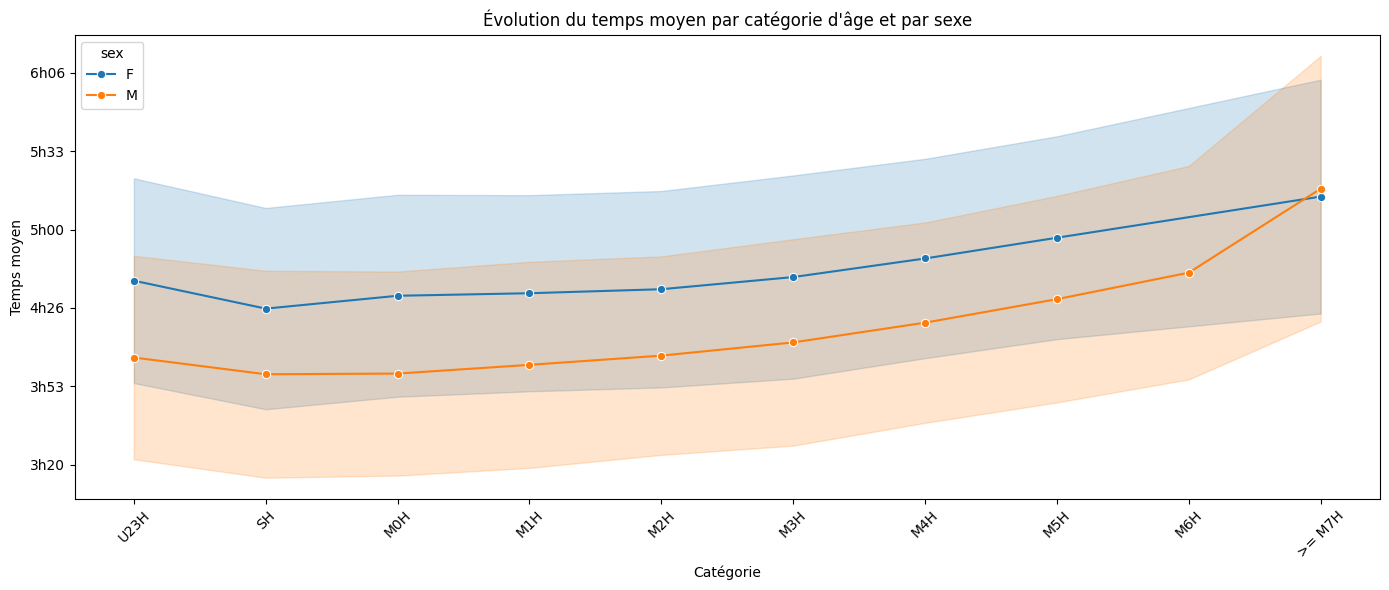

In [6]:
def evol_tps_age():
    
    # Regroupement des catégories jeunes en U23H/U23F
    df_cat = df.with_columns(
        pl.when(
            ~pl.col("category").str.starts_with("M") & 
            ~pl.col("category").str.starts_with("S")
        )
        .then(
            pl.when(pl.col("sex") == "M")
            .then(pl.lit("U23H"))
            .otherwise(pl.lit("U23F"))
        )
        .otherwise(pl.col("category"))
        .alias("category")
    )

    # Identification des catégories représentant moins de 1% par sexe
    seuil_h = total_h * 0.01
    seuil_f = total_f * 0.01

    df_count = (
        df_cat.group_by("category", "sex")
        .agg(pl.len().alias("n"))
        .with_columns(
            pl.when(pl.col("sex") == "M")
            .then(pl.col("n") < seuil_h)
            .otherwise(pl.col("n") < seuil_f)
            .alias("a_regrouper")
        )
    )

    cats_a_regrouper = (
        df_count
        .filter(pl.col("a_regrouper"))
        .select("category", "sex")
    )

    # Regroupement des catégories âgées
    cats_h = cats_a_regrouper.filter(pl.col("sex") == "M")["category"].to_list()
    cats_f = cats_a_regrouper.filter(pl.col("sex") == "F")["category"].to_list()

    df_cat = df_cat.with_columns(
        pl.when(
            pl.col("category").is_in(cats_h) &
            (pl.col("sex") == "M")
        )
        .then(pl.lit(">= M7H"))
        .when(
            pl.col("category").is_in(cats_f) &
            (pl.col("sex") == "F")
        )
        .then(pl.lit(">= M6F"))
        .otherwise(pl.col("category"))
        .alias("category")
    )

    ordre = {
        "U23H": 0, "U23F": 0,
        "SH": 1, "SF": 1,
        "M0H": 2, "M0F": 2,
        "M1H": 3, "M1F": 3,
        "M2H": 4, "M2F": 4,
        "M3H": 5, "M3F": 5,
        "M4H": 6, "M4F": 6,
        "M5H": 7, "M5F": 7,
        "M6H": 8, "M6F": 8,
        ">= M7H": 9, ">= M6F": 9,
    }

    # On passe les données non agrégées à Seaborn
    df_plot = (
        df_cat.with_columns(
            pl.col("category").replace(ordre).cast(pl.Int32).alias("ordre")
        )
        .sort("ordre")
        .to_pandas()
    )

    labels_h = (
        df_plot[df_plot["sex"] == "M"]
        .drop_duplicates("ordre")
        .sort_values("ordre")["category"]
        .tolist()
    )
    
    def format_seconds(x, pos):
        h = int(x // 3600)
        m = int((x % 3600) // 60)
        return f"{h}h{m:02d}"

    fig, ax = plt.subplots(figsize=(14, 6))

    sns.lineplot(
        data=df_plot,
        x="ordre",
        y="realTime",
        hue="sex",
        marker="o",
        errorbar="sd",
        ax=ax,
    )

    ax.xaxis.set_major_locator(ticker.FixedLocator(range(len(labels_h))))
    ax.xaxis.set_major_formatter(ticker.FixedFormatter(labels_h))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_seconds))

    plt.xlabel("Catégorie")
    plt.ylabel("Temps moyen")
    plt.title("Évolution du temps moyen par catégorie d'âge et par sexe")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

evol_tps_age()

In [ ]:
def repart_pays():
    """Tableau des 10 nationalités les plus représentées hors France,
    classées par temps moyen croissant."""

    df_nat = (
        df.filter(pl.col("nationality") != "FR")
        .group_by("nationality")
        .agg([
            pl.len().alias("n"),
            pl.col("realTime").mean().alias("temps_moyen")
        ])
        .sort("n", descending=True)
        .head(10)
        .sort("temps_moyen")
        .with_columns([
            (pl.col("n") / total * 100).alias("pct_total"),
            pl.col("temps_moyen").map_elements(
                lambda x: f"{int(x)//3600}:{int(x)%3600//60:02d}:{int(x)%60:02d}",
                return_dtype=pl.String
            ).alias("temps_moyen_fmt")
        ])
        .drop("temps_moyen")
    ).sort("pct_total", descending=True)

    return (
        gt.GT(df_nat.to_pandas(), rowname_col="nationality")
        .tab_header(title="Les 10 nationalités les plus représentées (hors France)")
        .cols_label(
            n="Nombre d'athlètes",
            pct_total="Part du peloton",
            temps_moyen_fmt="Temps moyen",
        )
        .fmt_number(columns=["n"], decimals=0)
        .fmt_percent(columns=["pct_total"], decimals=1, scale_values=False)
        .data_color(columns=["pct_total"], palette="Blues")
    )

GT(_tbl_data=  nationality     n  pct_total temps_moyen_fmt
0          GB  4648   8.086713         4:19:32
1          US  1857   3.230858         4:38:56
2          DE  1040   1.809419         4:19:47
3          IT   886   1.541486         4:10:01
4          BE   836   1.454495         4:10:51
5          NL   612   1.064774         4:08:20
6          IE   553   0.962124         4:12:04
7          BR   435   0.756824         4:19:34
8          ES   431   0.749865         4:03:42
9          CH   362   0.629817         4:12:33, _body=<great_tables._gt_data.Body object at 0x7fd22fd8fb10>, _boxhead=Boxhead([ColInfo(var='nationality', type=<ColInfoTypeEnum.stub: 2>, column_label='nationality', column_align='left', column_width=None), ColInfo(var='n', type=<ColInfoTypeEnum.default: 1>, column_label="Nombre d'athlètes", column_align='right', column_width=None), ColInfo(var='pct_total', type=<ColInfoTypeEnum.default: 1>, column_label='Part du peloton', column_align='right', column_width=None), ColInfo(var='temps_moyen_fmt', type=<ColInfoTypeEnum.default: 1>, column_label='Temps moyen', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fd22c5fb7f0>, _spanners=Spanners([]), _heading=Heading(title='Les 10 nationalités les plus représentées (hors France)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fd1f050ff50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fd1f050fdd0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='pct_total', rows=[0], mask=None), grpname=None, colname='pct_total', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#08306b')]), StyleInfo(locname=LocBody(columns='pct_total', rows=[1], mask=None), grpname=None, colname='pct_total', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#a6cee4')]), StyleInfo(locname=LocBody(columns='pct_total', rows=[2], mask=None), grpname=None, colname='pct_total', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#d8e7f5')]), StyleInfo(locname=LocBody(columns='pct_total', rows=[3], mask=None), grpname=None, colname='pct_total', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#dfebf7')]), StyleInfo(locname=LocBody(columns='pct_total', rows=[4], mask=None), grpname=None, colname='pct_total', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#e1edf8')]), StyleInfo(locname=LocBody(columns='pct_total', rows=[5], mask=None), grpname=None, colname='pct_total', rownum=5, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ebf4fb')]), StyleInfo(locname=LocBody(columns='pct_total', rows=[6], mask=None), grpname=None, colname='pct_total', rownum=6, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#eef5fc')]), StyleInfo(locname=LocBody(columns='pct_total', rows=[7], mask=None), grpname=None, colname='pct

In [ ]:
def meilleurs_pays():
    """Tableau des 20 nationalités les plus représentées parmi le premier centile."""

    q01 = df["realTime"].quantile(0.01)

    df_nat = (
        df.filter(pl.col("nationality") != "FR")
        .filter(pl.col("realTime") <= q01)
        .group_by("nationality")
        .agg([
            pl.len().alias("n"),
            pl.col("realTime").mean().alias("temps_moyen")
        ])
        .sort("temps_moyen", descending=False)
        .head(20)
        .with_columns([
            (pl.col("n") / df.filter(pl.col("realTime") <= q01).shape[0] * 100).alias("pct_total"),
            pl.col("temps_moyen").map_elements(
                lambda x: f"{int(x)//3600}:{int(x)%3600//60:02d}:{int(x)%60:02d}",
                return_dtype=pl.String
            ).alias("temps_moyen_fmt")
        ])
        .drop("temps_moyen")
    )

    return (
        gt.GT(df_nat.to_pandas(), rowname_col="nationality")
        .tab_header(title="Les 20 nationalités les plus représentées parmi le premier centile")
        .cols_label(
            n="Nombre d'athlètes",
            pct_total="Part du centile",
            temps_moyen_fmt="Temps moyen",
        )
        .fmt_number(columns=["n"], decimals=0)
        .fmt_percent(columns=["pct_total"], decimals=1, scale_values=False)
        .data_color(columns=["pct_total"], palette="Blues")
    )

GT(_tbl_data=   nationality   n  pct_total temps_moyen_fmt
0           DJ   1   0.173310         2:05:38
1           UG   3   0.519931         2:13:05
2           ET   6   1.039861         2:15:50
3           KE  10   1.733102         2:16:20
4           FI   1   0.173310         2:21:35
5           NO   4   0.693241         2:22:54
6           DZ   1   0.173310         2:29:54
7           PL   1   0.173310         2:32:21
8           CO   1   0.173310         2:33:20
9           DK   1   0.173310         2:34:44
10          IT  10   1.733102         2:35:33
11          CH   5   0.866551         2:35:59
12          US   8   1.386482         2:36:07
13          MA   5   0.866551         2:38:14
14          MX   1   0.173310         2:38:16
15          DE   5   0.866551         2:38:18
16          IE   3   0.519931         2:38:35
17          NL   1   0.173310         2:38:36
18          BR   4   0.693241         2:39:01
19          BE   7   1.213172         2:39:53, _body=<great_tables._gt_data.Body object at 0x7fd1f0582a30>, _boxhead=Boxhead([ColInfo(var='nationality', type=<ColInfoTypeEnum.stub: 2>, column_label='nationality', column_align='left', column_width=None), ColInfo(var='n', type=<ColInfoTypeEnum.default: 1>, column_label="Nombre d'athlètes", column_align='right', column_width=None), ColInfo(var='pct_total', type=<ColInfoTypeEnum.default: 1>, column_label='Part du centile', column_align='right', column_width=None), ColInfo(var='temps_moyen_fmt', type=<ColInfoTypeEnum.default: 1>, column_label='Temps moyen', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fd1f056d400>, _spanners=Spanners([]), _heading=Heading(title='Les 20 nationalités les plus représentées parmi le premier centile', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fd1f05885f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fd1f0588470>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='pct_total', rows=[0], mask=None), grpname=None, colname='pct_total', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#f7fbff')]), StyleInfo(locname=LocBody(columns='pct_total', rows=[1], mask=None), grpname=None, colname='pct_total', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#cbdff1')]), StyleInfo(locname=LocBody(columns='pct_total', rows=[2], mask=None), grpname=None, colname='pct_total', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#59a2cf')]), StyleInfo(locname=LocBody(columns='pct_total', rows=[3], mask=None), grpname=None, colname='pct_total', rownum=3, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#08306b')]), StyleInfo(locname=LocBody(columns='pct_total', rows=[4], mask=None), grpname=None, colname='pct_total', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#f7fbff')]), StyleInfo(locname=LocBody(columns='pct_total', rows=[5], mask=None), grpname=None, colname='pct_total', rownum=5, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellS